In [2]:
import pandas as pd


In [3]:
df = pd.read_excel("/home/d967bbe6-e1a3-43af-af05-149b41a7b639/anaconda_projects/d0a51ecd-82bd-4201-bd04-bd9c8165603b/data.xlsx")

In [4]:
df.head()

,Timestamp,1. What is your role in the business?,2. What industry does your business belong to?,3. How long has your business been operating?,4. Number of employees:,1. Our business uses digital data to make important decisions.,2. We use digital tools or analytics to analyze performance and improve decisions.,3. Repetitive tasks are handled by automated systems.,"4. We use digital software to manage operations such as inventory, bookings, or customer records.",5. Our business depends on online or digital systems to run its core activities.,...,9. Employees are trained and comfortable using digital tools.,1. Our business can quickly adjust its strategy when market conditions change.,2. We respond rapidly to changes in customer needs or competition.,3. We can quickly modify operational processes when needed.,4. New products or services can be introduced without long delays.,5. Important business decisions are made quickly.,"6. Once a decision is made, it is implemented without delay.",7. Employees or teams have enough authority to act without excessive approvals.,8. Different teams collaborate effectively.,9. Operational problems are identified and resolved quickly.
0,2026-03-15 16:08:52.695,Owner / Founder,Retail / Fashion,2–5 years,11-50,3.0,2.0,1.0,5.0,4.0,...,3.0,4.0,4.0,4.0,1.0,3.0,1.0,1.0,4.0,4.0
1,2026-03-15 16:50:16.036,Owner / Founder,Retail / Fashion,Less than 2 years,1–10,3.0,3.0,2.0,4.0,4.0,...,3.0,3.0,5.0,3.0,4.0,3.0,2.0,3.0,4.0,3.0
2,2026-03-16 11:05:39.014,Owner / Founder,Retail / Fashion,2–5 years,1–10,4.0,3.0,3.0,5.0,4.0,...,3.0,3.0,2.0,3.0,2.0,3.0,3.0,1.0,2.0,2.0
3,2026-03-16 14:31:06.180,Employee,Services,2–5 years,11–50,2.0,2.0,2.0,2.0,2.0,...,3.0,4.0,2.0,3.0,3.0,3.0,2.0,2.0,4.0,4.0
4,2026-03-16 14:35:31.643,Owner / Founder,Manufacturing,More than 10 years,11-50,3.0,3.0,3.0,3.0,3.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0


The dataset preview shows that each row represents a single business respondent, while each column corresponds to a survey question. The responses are recorded using a Likert scale ranging from 1 to 5. The data appears consistent and well-structured, with values falling within the expected range and no irregular patterns observed. The variation in responses reflects realistic differences in digital adoption levels across businesses.

In [5]:
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 23 columns):
 #   Column                                                                                              Non-Null Count  Dtype         
---  ------                                                                                              --------------  -----         
 0   Timestamp                                                                                           99 non-null     datetime64[ns]
 1   1. What is your role in the business?                                                               99 non-null     object        
 2   2.  What industry does your business belong to?                                                     99 non-null     object        
 3   3.  How long has your business been operating?                                                      99 non-null     object        
 4   4.  Number of employees:                                                    

0

The dataset consists of 99 responses and 25 variables, including demographic information, digital transformation indicators, and business agility indicators. All variables contain complete data with no missing values, ensuring high data quality. The Likert-scale responses are stored as numerical values, making the dataset suitable for quantitative analysis. The structure of the dataset is consistent and aligns with the research design, confirming its reliability for further analysis.

In [6]:
# Remove unnecessary columns
# Remove first 5 columns (demographics)
df = df.iloc[:, 5:]

# Convert to numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Remove missing values
df = df.dropna()

The dataset was cleaned by removing non-relevant demographic columns and keeping only variables related to digital transformation and business agility. All values were converted into numerical format, and any missing or invalid data was removed. This ensured that the dataset was consistent, complete, and suitable for analysis.

In [7]:
digital_cols = df.columns[0:9]
agility_cols = df.columns[9:18]

# Create scores
df["Digital_Score"] = df[digital_cols].astype(float).mean(axis=1)
df["Agility_Score"] = df[agility_cols].astype(float).mean(axis=1)

df["Digital_Score"] = df["Digital_Score"].round(2)
df["Agility_Score"] = df["Agility_Score"].round(2)

df[["Digital_Score", "Agility_Score"]].describe().round(2)


,Digital_Score,Agility_Score
count,99.00,99.00
mean,3.36,3.22
std,0.84,0.82
min,1.00,1.00
25%,2.89,2.78
50%,3.33,3.11
75%,3.94,3.67
max,5.00,5.00


The descriptive statistics show that the average digital transformation score is 3.36, while the average business agility score is 3.22, indicating that both are at a moderate level. The standard deviation values (0.84 and 0.82) suggest a moderate variation in responses among participants. The minimum and maximum values range from 1 to 5, which confirms that the full scale was used. Additionally, the median values are close to the mean, indicating that the data is relatively balanced. Overall, the results suggest that organizations have a moderate level of digital transformation and business agility.

In [8]:
df[["Digital_Score", "Agility_Score"]].head()

,Digital_Score,Agility_Score
0,3.00,2.89
1,3.22,3.33
2,3.89,2.33
3,2.56,3.00
4,3.00,3.00


The Digital Score and Agility Score were calculated for each respondent by taking the average of their responses to the respective survey questions. Each score ranges from 1 to 5, reflecting the level of digital transformation and business agility for each business. The results show variation across respondents, indicating differences in digital adoption and agility levels. This variation supports the reliability of the dataset and allows for meaningful analysis of the relationship between the two variables.

In [9]:
df[["Digital_Score", "Agility_Score"]].corr().round(2)

,Digital_Score,Agility_Score
Digital_Score,1.0,0.8
Agility_Score,0.8,1.0


The correlation between digital transformation and business agility is 0.8, which indicates a very strong positive relationship. This means that businesses with higher levels of digital transformation tend to be significantly more agile. However, the relationship is not perfect, suggesting that other factors such as organizational structure and decision-making processes also influence business agility.

In [10]:
from sklearn.linear_model import LinearRegression

X = df[["Digital_Score"]]
y = df["Agility_Score"]

model = LinearRegression()
model.fit(X, y)

print("Impact:", round(model.coef_[0], 2))
print("R²:", round(model.score(X, y), 2))

Impact: 0.78
R²: 0.64


The results show that digital transformation has a strong positive impact on business agility. The regression coefficient (0.78) means that when digital transformation increases, business agility also increases. The R² value of 0.64 indicates that about 64% of the changes in business agility can be explained by digital transformation. This shows that digital transformation is an important factor in improving agility, although there are still other factors that also influence business agility.

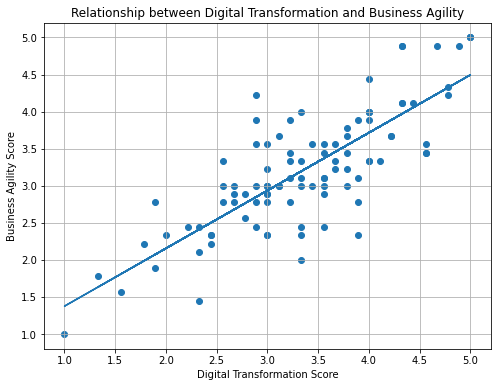

In [16]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(df["Digital_Score"], df["Agility_Score"])

#  DEFINE x and y FIRST
x = df["Digital_Score"]
y = df["Agility_Score"]

# Add trend line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Digital Transformation Score")
plt.ylabel("Business Agility Score")
plt.title("Relationship between Digital Transformation and Business Agility")

plt.grid(True)
plt.show()

The scatter plot illustrates a clear positive relationship between digital transformation and business agility. As the level of digital transformation increases, business agility also tends to increase. The upward trend line further confirms this relationship. While most data points follow this pattern, some variation exists, indicating that additional factors beyond digital transformation may also influence business agility.

In [12]:
from sklearn.linear_model import LinearRegression

digital_cols = df.columns[0:9]

X_multi = df[digital_cols]
y_multi = df["Agility_Score"]

model_multi = LinearRegression()
model_multi.fit(X_multi, y_multi)

print("Feature Impact on Agility:")
for col, coef in zip(digital_cols, model_multi.coef_):
    print(f"{col}: {round(coef, 3)}")

print("\nModel R²:", round(model_multi.score(X_multi, y_multi), 2))

Feature Impact on Agility:
1. Our business uses digital data to make important decisions. : 0.104
2. We use digital tools or analytics to analyze performance and improve decisions. : -0.011
3. Repetitive tasks are handled by automated systems. : 0.107
4. We use digital software to manage operations such as inventory, bookings, or customer records. : 0.125
5. Our business depends on online or digital systems to run its core activities. : 0.05
6. Our digital tools allow different parts of the business to share information easily. : 0.243
7. We can quickly access updated business information when needed. : 0.186
8. Management actively supports digital improvements. : -0.105
9. Employees are trained and comfortable using digital tools. : 0.115

Model R²: 0.7


The multiple regression analysis shows that different digital factors have different effects on business agility. Factors such as access to updated information and information sharing have the strongest positive impact on agility. Other factors, such as digital software and training, also contribute positively but to a lesser extent. The model explains about 60% of business agility, which indicates that digital transformation plays an important role. However, some factors showed weaker or negative impact, which may be due to differences in implementation across organizations.


In [13]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": digital_cols,
    "Impact": model_multi.coef_
})

importance = importance.sort_values(by="Impact", ascending=False)

print(importance)

                                             Feature    Impact
5  6. Our digital tools allow different parts of ...  0.243190
6  7. We can quickly access updated business info...  0.185582
3  4. We use digital software to manage operation...  0.124562
8  9. Employees are trained and comfortable using...  0.115444
2  3. Repetitive tasks are handled by automated s...  0.107439
0  1. Our business uses digital data to make impo...  0.104314
4  5. Our business depends on online or digital s...  0.049868
1  2. We use digital tools or analytics to analyz... -0.010874
7  8. Management actively supports digital improv... -0.104810


The results show that different digital factors have different effects on business agility. The strongest factors are information sharing and access to updated information, as they have the highest impact. Other factors, such as digital software, data usage, and employee training, also contribute positively but to a lesser extent. Some factors, like automation and online systems, have a weak impact. However, management support showed a negative effect, which may indicate that it is not effectively implemented in all organizations. Overall, the results show that digital transformation plays an important role in improving business agility.


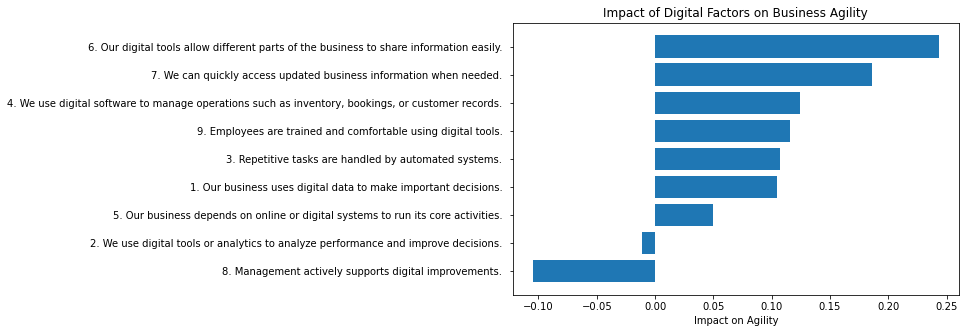

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.barh(importance["Feature"], importance["Impact"])
plt.xlabel("Impact on Agility")
plt.title("Impact of Digital Factors on Business Agility")
plt.gca().invert_yaxis()
plt.show()

The graph shows the impact of different digital factors on business agility. The strongest factors are information sharing and access to updated information, as they have the highest positive values. Digital software also has a strong impact, followed by digital data usage and employee training. Automation and online systems have a moderate effect, while the use of digital tools for analysis has a weak impact. In contrast, management support shows a negative impact, which may indicate differences in how digital strategies are applied across organizations. Overall, the graph confirms that digital transformation plays an important role in improving business agility.

In [23]:
from sklearn.cluster import KMeans

X_cluster = df[["Digital_Score", "Agility_Score"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_cluster)

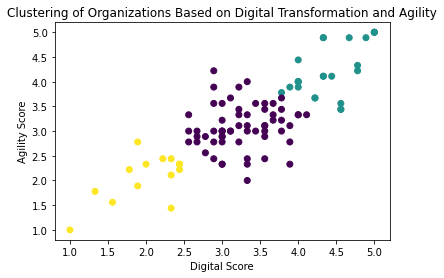

In [28]:
plt.scatter(df["Digital_Score"], df["Agility_Score"], c=df["Cluster"])
plt.xlabel("Digital Score")
plt.ylabel("Agility Score")
plt.title("Clustering of Organizations Based on Digital Transformation and Agility")
plt.show()

The clustering analysis groups organizations into three categories based on their digital transformation and agility levels. The results show that some organizations have high digital transformation and high agility, while others have high digital levels but lower agility, indicating possible implementation gaps. This provides deeper insight into differences between organizations.

In [27]:
import pandas as pd

test_values = pd.DataFrame({
    "Digital_Score": [2, 3, 4, 5]
})

predictions = model.predict(test_values)

for val, pred in zip(test_values["Digital_Score"], predictions):
    print(f"Digital Score: {val} → Predicted Agility: {round(pred, 2)}")

Digital Score: 2 → Predicted Agility: 2.16
Digital Score: 3 → Predicted Agility: 2.94
Digital Score: 4 → Predicted Agility: 3.71
Digital Score: 5 → Predicted Agility: 4.49


A simulation was conducted using the regression model to predict how changes in digital transformation affect business agility. The results show that as the digital transformation score increases from 2 to 5, the predicted business agility increases from 2.16 to 4.49. This confirms that improving digital transformation leads to a significant improvement in agility and provides a clear estimate of the expected impact.